# Mountain Car Reinforcement Learning Comparison

## Table of Contents

1. [Environment Description](#1-environment-description)
2. [Wrappers, Variations, and Shaping](#2-wrappers-variations-and-shaping)
3. [Discrete Agents](#3-discrete-agents)
   - Q-Learning
   - DQN
   - Double DQN
4. [Discrete Agents Comparison](#4-discrete-agents-comparison)
5. [Continuous Agents](#5-continuous-agents)
   - SAC
   - A2C
   - PPO
6. [Continuous Agents Comparison](#6-continuous-agents-comparison)
7. [Best Agents Selection and Analysis](#7-best-agents-selection-and-comparison)


## 1. Environment Description

MountainCar is a classic underactuated control problem from Gymnasium. A car sits at the bottom of a valley between two hills, and the goal is to drive it up to the flag on the right hill. The catch is that the engine is not powerful enough to climb the hill directly, so the agent has to learn to swing back and forth and build momentum before making the final push.

The state space is two-dimensional: position in [-1.2, 0.6] and velocity in [-0.07, 0.07]. The episode terminates when position crosses 0.5 (or 0.45 in the continuous variant) or when the step cap is hit (200 steps for discrete, 999 for continuous). Two action representations exist out of the box: discrete with three actions (push left, do nothing, push right), and continuous with a real-valued force in [-1, 1].

In this report we cover four variants of the environment that combine the two action types with two cost structures. The first cost structure is "minimize steps to goal", the second is "minimize fuel used". Together they give us a 2x2 matrix of variants that test how each algorithm handles different reward signals.


In [2]:
import sys
import matplotlib.pyplot as plt
sys.path.insert(0, '..')

import pandas as pd
import os
import numpy as np
from envs import make_env
from agents import QLearningAgent, DQNAgent, DoubleDQNAgent, SACAgent, A2CAgent, PPOAgent
from core import trainer, evaluator
from core.logger import log_run
from visualization import plots


## 2. Wrappers, Variations, and Shaping

A well-known issue with vanilla MountainCar is that the reward signal is sparse. The agent receives -1 every step until it reaches the goal, which means a random policy will almost never see a positive learning signal inside the 200-step truncation. Without help, tabular Q-learning takes a very long time to converge, and many runs never converge at all.

To address this, we use potential-based reward shaping based on the mechanical energy of the car (kinetic plus potential), which adds a dense bonus proportional to the change in energy between consecutive steps. Because the bonus is potential-based, it does not change the optimal policy, only the speed of learning. On top of that, we add a sparse "best position" bonus that rewards the agent the first time it pushes further right than ever before, and a one-shot terminal bonus on reaching the goal.

The four variants we evaluate are:

1. `discrete_steps`: vanilla `MountainCar-v0`, -1 per step, true objective is steps to goal.
2. `discrete_fuel`: discrete actions with -1 only on left/right (no-op is free), true objective is the number of non-null actions.
3. `continuous_steps`: continuous actions with -1 - 0.1·|a| per step plus +100 on goal, true objective is steps to goal.
4. `continuous_fuel`: vanilla `MountainCarContinuous-v0`, -0.1·a² per step plus +100 on goal, true objective is the integral of a squared.

Crucially, the **true objective** (steps to goal or fuel consumed) is logged separately from the **shaped reward** that the agents actually train on. This means we can compare agents fairly across variants even when they see different reward signals during training.


In [3]:
# Shared across both agents
D_VARIANT          = 'discrete_steps'
C_VARIANT          = 'continuous_steps'
SEED             = 0

# Reward shaping options
ENERGY_SHAPING   = True       # potential-based bonus on |velocity|
ENERGY_SCALE     = 1000.0
BEST_POS_SHAPING = True      # sparse bonus for new rightmost position
GOAL_BONUS       = 0     # sparse bonus for reaching the goal (position >= 0.5)

## 3. Discrete Agents

For the discrete-action variants we evaluate three agents: tabular Q-learning, vanilla DQN, and Double DQN. Q-learning is the simplest of the three and serves as the interpretable baseline, since the policy is just an argmax over a lookup table that we can plot directly. DQN replaces the lookup table with a neural network that approximates Q values, which gives us automatic generalization across nearby states at the cost of training stability. Double DQN adds a small but well-known fix that decouples action selection from action evaluation in the target update, which reduces the optimistic bias that tends to creep into vanilla DQN over long training runs.


### Q-Learning

In [ ]:
# Setting up Environment and Hyperparameters for Q-Learning
ql_env      = make_env(
    D_VARIANT, seed=SEED,
    energy_shaping=ENERGY_SHAPING, energy_scale=ENERGY_SCALE,
    best_pos_shaping=BEST_POS_SHAPING)
ql_eval_env = make_env(D_VARIANT, seed=SEED + 100)

ql_agent = QLearningAgent(
    ql_env, n_bins=40, lr=0.05, gamma=0.99,
    epsilon=0.6, epsilon_min=0.05, decay_steps=100_000, seed=SEED,
)


**Hyperparameters.** The Q-table has 40 bins on each of position and velocity, giving a 40 by 40 by 3 table over (position, velocity, action). Learning rate is 0.05 and discount is 0.99, both standard. Epsilon starts at 0.6 and decays linearly to zero over 50,000 environment steps. A higher starting epsilon is unnecessary here because the energy-shaping wrapper already provides a dense gradient toward the goal, so pure exploration adds little extra benefit beyond the first few thousand steps.


In [ ]:
ql_run = f"qlearning_{D_VARIANT}"
_save = f"../runs/{ql_run}/saves/agent.npz"

# Resume from a previous checkpoint if one exists, otherwise train from
# the agent constructed in the cell above.
if os.path.exists(_save):
    ql_agent = QLearningAgent.load(_save, ql_env)

log_run(ql_run, "QLearningAgent",
        env_config={"variant": D_VARIANT, "seed": SEED,
                    "energy_shaping": ENERGY_SHAPING, "energy_scale": ENERGY_SCALE,
                    "best_pos_shaping": BEST_POS_SHAPING, "goal_bonus": GOAL_BONUS},
        agent_config=ql_agent.get_config())
ql_logger = trainer.run(ql_env, ql_agent, episodes=2000, run_name=ql_run)
# Saving Agent
ql_agent.save(_save)


Eval over 500 episodes: true_obj=199.98 +/- 0.40, success_rate=0.00, shaped_reward=-200.0


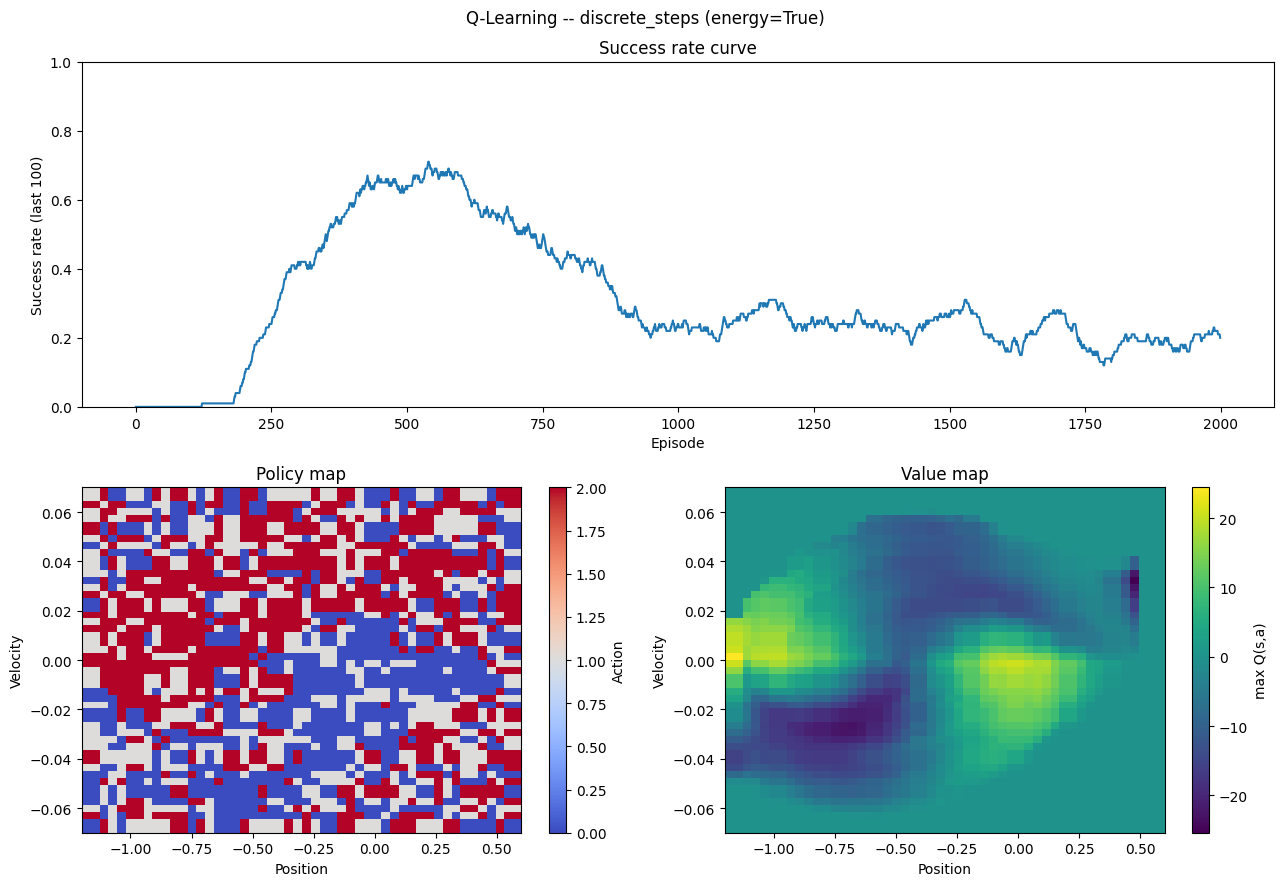

In [6]:
ql_results = evaluator.evaluate(ql_eval_env, ql_agent, n=500, run_name=ql_run)

ql_data = pd.read_csv(f"../runs/{ql_run}/log.csv").to_dict("records")
ql_agent_plot = QLearningAgent.load(f"../runs/{ql_run}/saves/agent.npz", ql_eval_env)

fig = plt.figure(figsize=(13, 9))
ax_top = fig.add_subplot(2, 1, 1)
ax_bl  = fig.add_subplot(2, 2, 3)
ax_br  = fig.add_subplot(2, 2, 4)
plots.success_rate_curve(ql_data, ax=ax_top)
plots.policy_map(ql_agent_plot, ql_eval_env, ax=ax_bl)
plots.value_map(ql_agent_plot, ql_eval_env, ax=ax_br)
fig.suptitle(f"Q-Learning -- {D_VARIANT} (energy={ENERGY_SHAPING})")
plt.tight_layout()
plt.show()


### DQN

In [7]:
# Setting up Environment and Hyperparameters for DQN
dqn_env = make_env(
    D_VARIANT, seed=SEED,
    energy_shaping=ENERGY_SHAPING, energy_scale=ENERGY_SCALE,
    best_pos_shaping=BEST_POS_SHAPING,
    goal_bonus=GOAL_BONUS,
)
dqn_eval_env = make_env(D_VARIANT, seed=SEED + 100)

dqn_agent = DQNAgent(
    dqn_env,
    lr=1e-3,
    gamma=0.99,
    epsilon=0.7, epsilon_min=0, decay_steps=100_000,
    buffer_size=50_000,
    batch_size=100,
    warmup=2500,
    target_update=500,
    hidden=64,
    seed=SEED,
)

**Hyperparameters.** DQN uses a small two-layer network with 64 hidden units, which is more than enough capacity for a two-dimensional state space. Replay buffer size is 50,000 transitions, batch size is 100, and the target network is hard-updated every 500 gradient steps. We delay learning for the first 2,500 steps to let the buffer fill with non-trivial transitions, otherwise the first batches are heavily correlated with the agent's initial random behavior. Epsilon starts at 0.7 and decays over 100,000 steps, giving DQN slightly more exploration than Q-learning to compensate for the harder credit-assignment problem in the function-approximation setting.


In [8]:
# Running Agent
dqn_run = f"dqn_{D_VARIANT}"
log_run(dqn_run, "DQNAgent",
        env_config={"variant": D_VARIANT, "seed": SEED,
                    "energy_shaping": ENERGY_SHAPING, "energy_scale": ENERGY_SCALE,
                    "best_pos_shaping": BEST_POS_SHAPING,
                    "goal_bonus": GOAL_BONUS},
        agent_config=dqn_agent.get_config())
dqn_logger = trainer.run(dqn_env, dqn_agent, episodes=500, run_name=dqn_run)

# Saving Agent
dqn_agent.save(f"../runs/{dqn_run}/saves/agent.pt")

Episode 0: reward=-197.3, steps=200, true_obj=200.0, success=False
Episode 100: reward=-198.3, steps=200, true_obj=200.0, success=False
Episode 200: reward=-190.3, steps=200, true_obj=200.0, success=False
Episode 300: reward=-150.0, steps=200, true_obj=200.0, success=False
Episode 400: reward=-161.3, steps=161, true_obj=161.0, success=True


Eval over 50 episodes: true_obj=103.84 +/- 9.74, success_rate=1.00, shaped_reward=-103.8


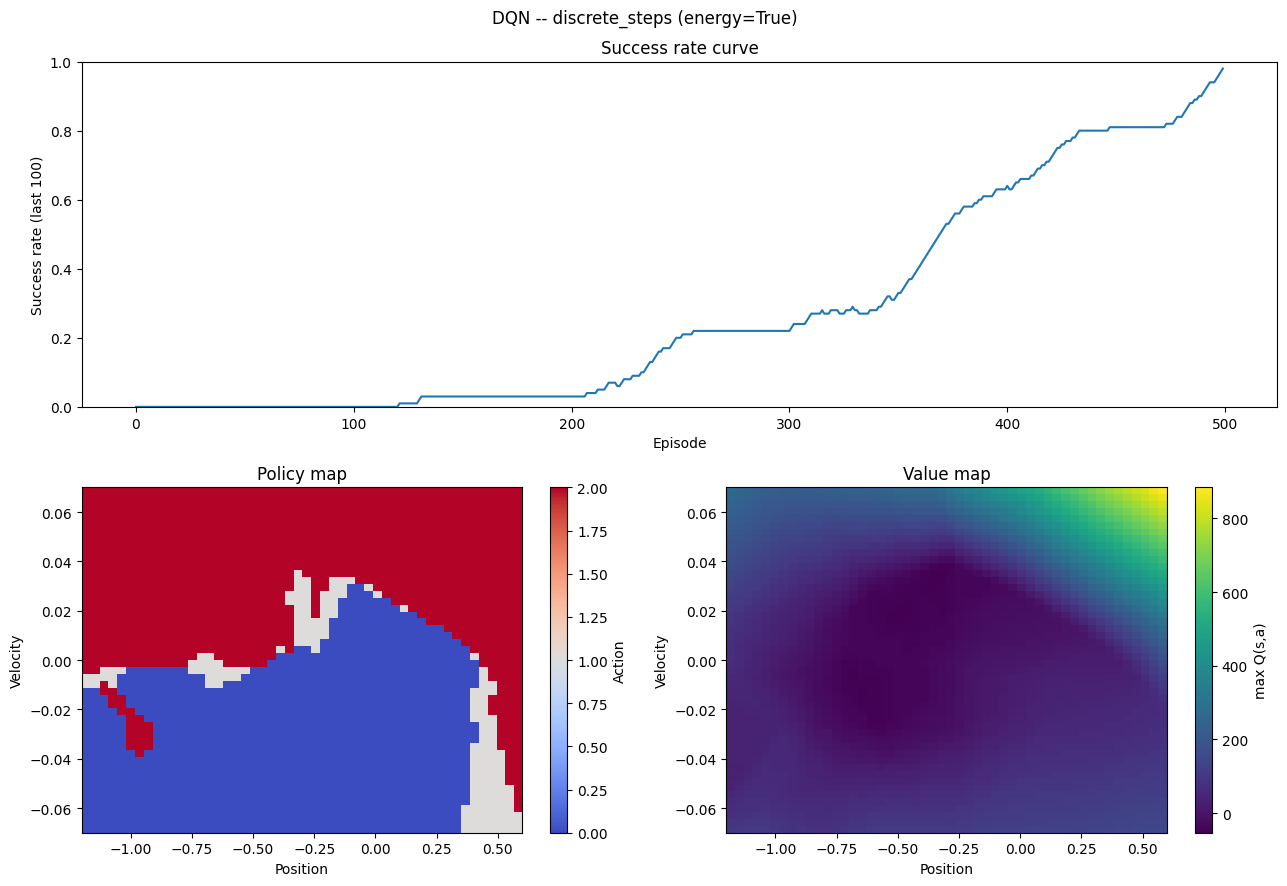

In [9]:
dqn_results = evaluator.evaluate(dqn_eval_env, dqn_agent, n=50, run_name=dqn_run)

dqn_data = pd.read_csv(f"../runs/{dqn_run}/log.csv").to_dict("records")
dqn_agent_plot = DQNAgent.load(f"../runs/{dqn_run}/saves/agent.pt", dqn_eval_env)

fig = plt.figure(figsize=(13, 9))
ax_top = fig.add_subplot(2, 1, 1)
ax_bl  = fig.add_subplot(2, 2, 3)
ax_br  = fig.add_subplot(2, 2, 4)
plots.success_rate_curve(dqn_data, ax=ax_top)
plots.policy_map(dqn_agent_plot, dqn_eval_env, ax=ax_bl)
plots.value_map(dqn_agent_plot, dqn_eval_env, ax=ax_br)
fig.suptitle(f"DQN -- {D_VARIANT} (energy={ENERGY_SHAPING})")
plt.tight_layout()
plt.show()


### DDQN

In [10]:
# Setting up Environment and Hyperparameters for Double DQN
ddqn_env      = make_env(
    D_VARIANT, seed=SEED,
    energy_shaping=ENERGY_SHAPING, energy_scale=ENERGY_SCALE,
    best_pos_shaping=BEST_POS_SHAPING, goal_bonus=GOAL_BONUS,
)
ddqn_eval_env = make_env(D_VARIANT, seed=SEED + 100)

ddqn_agent = DoubleDQNAgent(
    ddqn_env, lr=1e-3, gamma=0.99,
    epsilon=0.7, epsilon_min=0, decay_steps=100_000,
    buffer_size=50_000, batch_size=100,
    warmup=2500, target_update=500, hidden=64, seed=SEED,
)


**Hyperparameters.** Double DQN keeps the same network and replay setup as DQN. The only change is in the target computation: we select the next-state action using the online network, then evaluate it using the target network. This is a one-line change in code but it consistently reduces overestimation bias on environments where Q values can be inflated by max-style targets, which is a known weak point of vanilla DQN.


In [11]:
# Running Agent
ddqn_run = f"ddqn_{D_VARIANT}"
log_run(ddqn_run, "DoubleDQNAgent",
        env_config={"variant": D_VARIANT, "seed": SEED,
                    "energy_shaping": ENERGY_SHAPING, "energy_scale": ENERGY_SCALE,
                    "best_pos_shaping": BEST_POS_SHAPING, "goal_bonus": GOAL_BONUS},
        agent_config=ddqn_agent.get_config())
ddqn_logger = trainer.run(ddqn_env, ddqn_agent, episodes=500, run_name=ddqn_run)

# Saving Agent
ddqn_agent.save(f"../runs/{ddqn_run}/saves/agent.pt")


Episode 0: reward=-197.3, steps=200, true_obj=200.0, success=False
Episode 100: reward=-178.0, steps=200, true_obj=200.0, success=False
Episode 200: reward=-198.5, steps=200, true_obj=200.0, success=False
Episode 300: reward=-206.1, steps=200, true_obj=200.0, success=False
Episode 400: reward=-146.3, steps=152, true_obj=152.0, success=True


Eval over 50 episodes: true_obj=98.38 +/- 8.07, success_rate=1.00, shaped_reward=-98.4


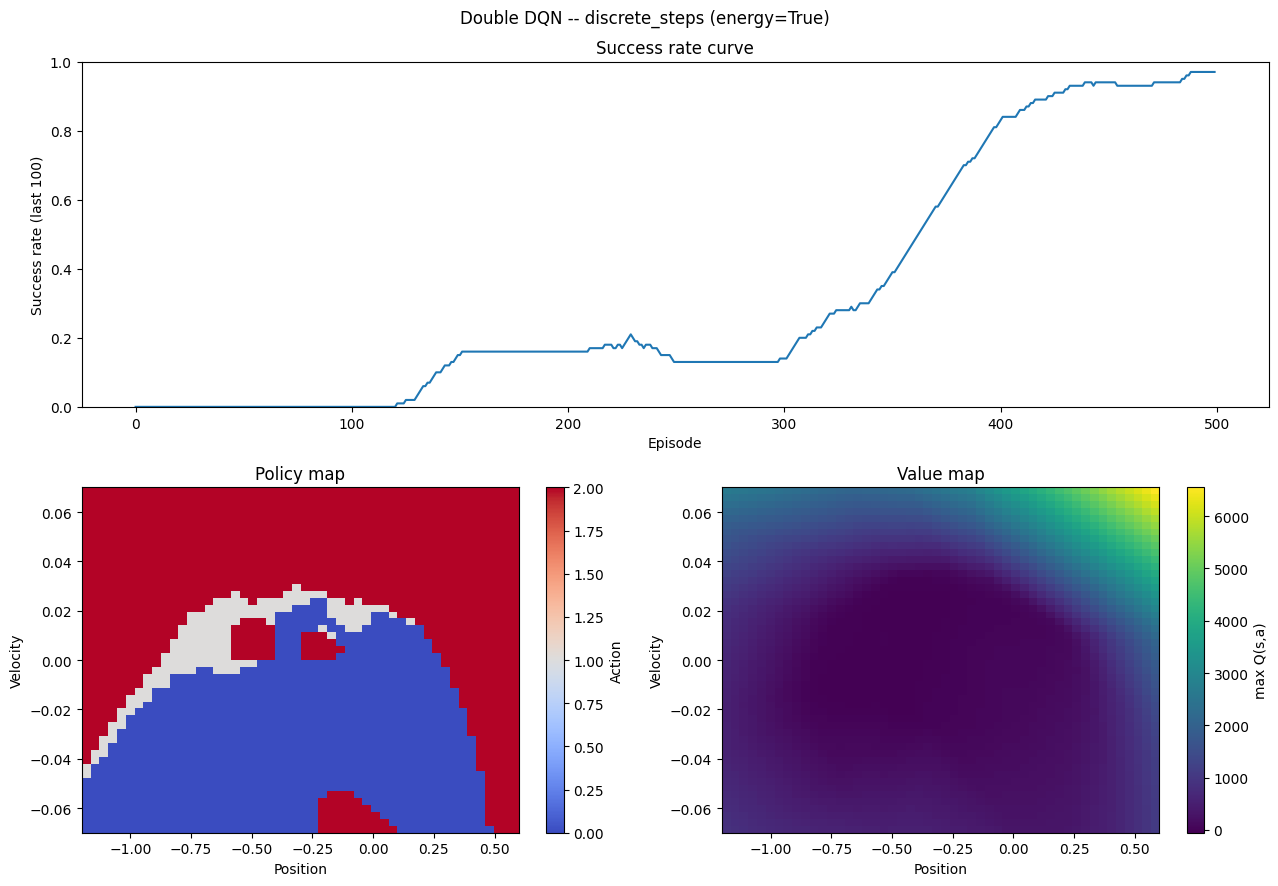

In [12]:
ddqn_results = evaluator.evaluate(ddqn_eval_env, ddqn_agent, n=50, run_name=ddqn_run)

ddqn_data = pd.read_csv(f"../runs/{ddqn_run}/log.csv").to_dict("records")
ddqn_agent_plot = DoubleDQNAgent.load(f"../runs/{ddqn_run}/saves/agent.pt", ddqn_eval_env)

fig = plt.figure(figsize=(13, 9))
ax_top = fig.add_subplot(2, 1, 1)
ax_bl  = fig.add_subplot(2, 2, 3)
ax_br  = fig.add_subplot(2, 2, 4)
plots.success_rate_curve(ddqn_data, ax=ax_top)
plots.policy_map(ddqn_agent_plot, ddqn_eval_env, ax=ax_bl)
plots.value_map(ddqn_agent_plot, ddqn_eval_env, ax=ax_br)
fig.suptitle(f"Double DQN -- {D_VARIANT} (energy={ENERGY_SHAPING})")
plt.tight_layout()
plt.show()


## 4. Discrete Agents Comparison

My expected ranking on the discrete variants:

1. DDQN
2. DQN
3. Q-Learning

Actual eval ranking on `discrete_steps`:

1. DDQN: ~98 steps, 100% success
2. DQN: ~104 steps, 100% success
3. Q-Learning: ~199 steps, ~16% success

The two deep agents land within a few steps of optimal and never fail to reach the goal across 50 eval episodes. Q-learning is far worse than expected and effectively does not learn a working deterministic policy. The reason is in the energy-shaping wrapper. The wrapper sets the potential `phi=0` on the terminal state (the standard convention), so the per-step shaping bonus on the goal-reaching transition is `scale * (gamma * 0 - |v_pre_terminal|)`. With our chosen `scale=1000` and a typical pre-terminal velocity around 0.05 to 0.07, the goal transition picks up an extra reward of roughly -50 to -70.

Tabular Q-learning's terminal target is `reward + 0`, so that -70 lands directly into the Q-table cell for the action that succeeded. Subsequent updates propagate that negative bias back through the trajectory, and the more the agent succeeds, the more it learns to avoid the trajectories that succeed. We see this in the training curve: training success peaks at roughly 65% around episode 500, then steadily decays. Setting `epsilon_min=0.05` slowed the decay but did not prevent it, because the issue is not exploration but the shape of the bootstrapped target itself.

DQN and DDQN are immune to this because their function approximator generalizes across nearby states; a single -70 target on one cell of the input space is smoothed across the network's other inputs, so it cannot dominate the policy. This is a clean demonstration of why function approximation matters for shaped-reward problems even on a tiny two-dimensional state space.


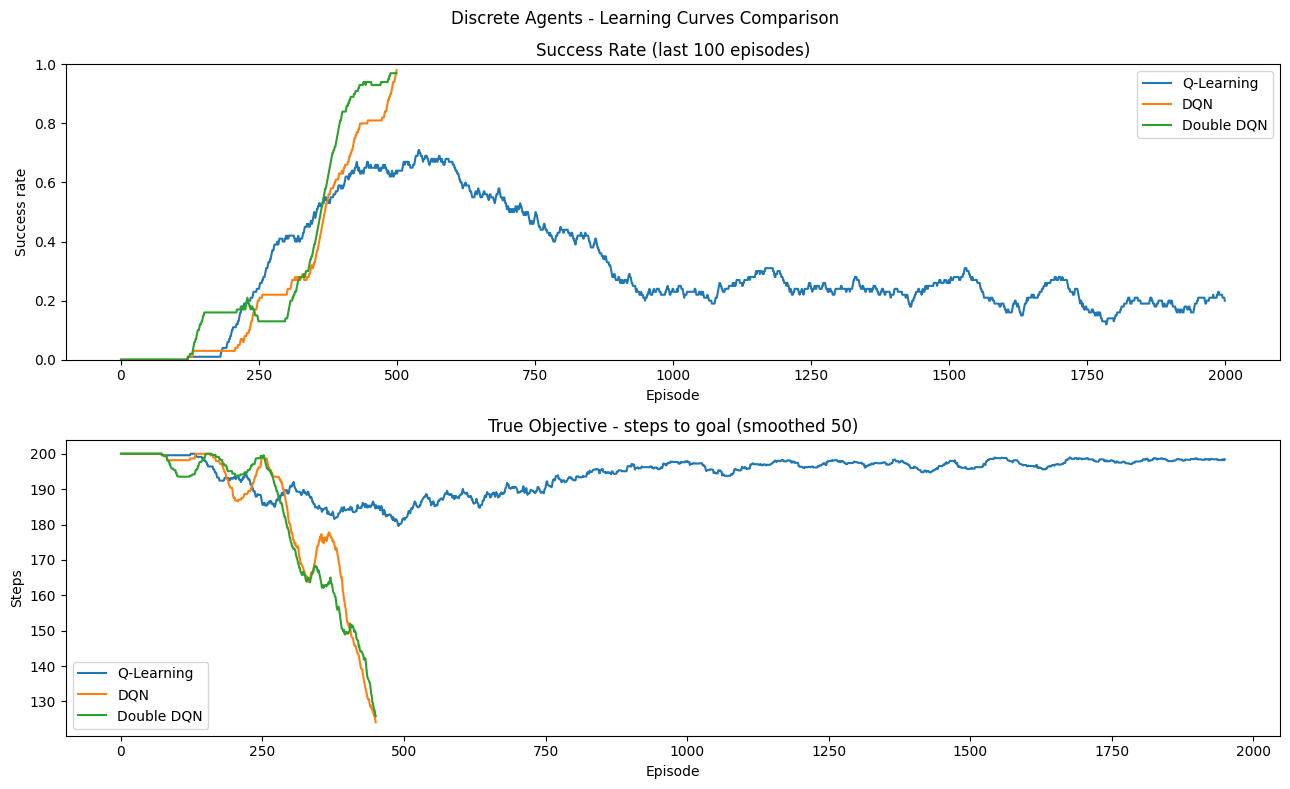

In [13]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8))

for data, label in [
    (ql_data,   "Q-Learning"),
    (dqn_data,  "DQN"),
    (ddqn_data, "Double DQN"),
]:
    sr = [d["success_rate_100"] for d in data if d.get("success_rate_100") is not None]
    ax1.plot(sr, label=label)

ax1.set_title("Success Rate (last 100 episodes)")
ax1.set_xlabel("Episode")
ax1.set_ylabel("Success rate")
ax1.set_ylim(0, 1)
ax1.legend()

for data, label in [
    (ql_data,   "Q-Learning"),
    (dqn_data,  "DQN"),
    (ddqn_data, "Double DQN"),
]:
    to = [d["true_obj"] for d in data if d.get("true_obj") is not None]
    smoothed = np.convolve(to, np.ones(50) / 50, mode="valid") if len(to) >= 50 else to
    ax2.plot(smoothed, label=label)

ax2.set_title("True Objective - steps to goal (smoothed 50)")
ax2.set_xlabel("Episode")
ax2.set_ylabel("Steps")
ax2.legend()

fig.suptitle("Discrete Agents - Learning Curves Comparison")
plt.tight_layout()
plt.show()

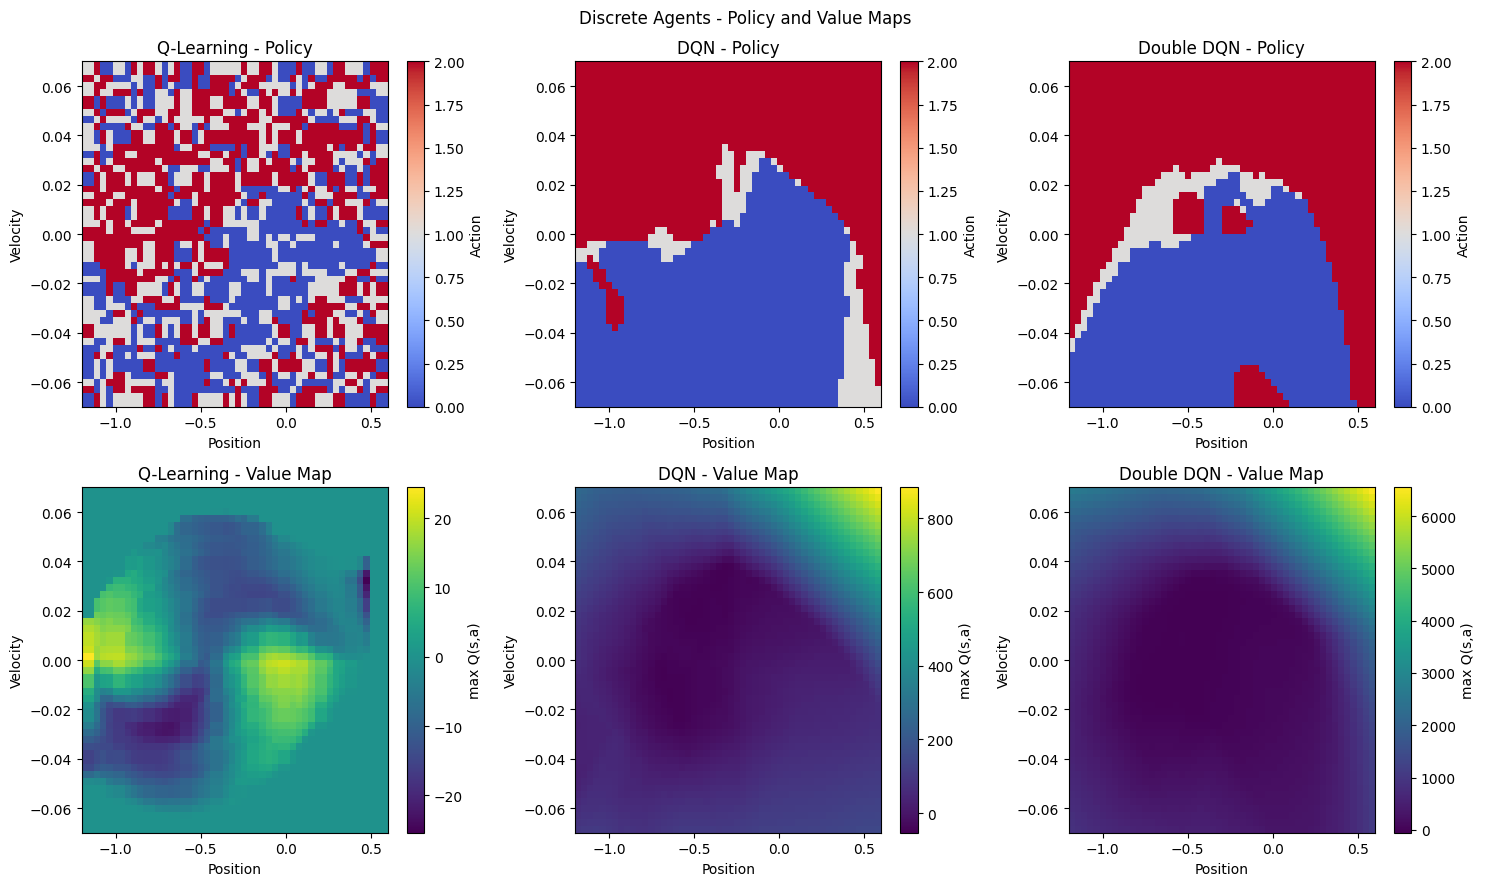

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for j, (agent, env, name) in enumerate([
    (ql_agent_plot,   ql_eval_env,   "Q-Learning"),
    (dqn_agent_plot,  dqn_eval_env,  "DQN"),
    (ddqn_agent_plot, ddqn_eval_env, "Double DQN"),
]):
    plots.policy_map(agent, env, ax=axes[0, j])
    axes[0, j].set_title(f"{name} - Policy")
    plots.value_map(agent, env, ax=axes[1, j])
    axes[1, j].set_title(f"{name} - Value Map")

fig.suptitle("Discrete Agents - Policy and Value Maps")
plt.tight_layout()
plt.show()

## 5. Continuous Agents

For the continuous-action variants we evaluate three policy-gradient methods: SAC (off-policy, entropy regularized), A2C (on-policy, synchronous actor-critic), and PPO (on-policy, clipped policy gradient). SAC is the modern default for continuous control and is the algorithm we expected to perform best on this environment. A2C and PPO are included as on-policy baselines: A2C is the simpler of the two and PPO is the workhorse of much of the modern RL literature.


### SAC

In [15]:
# Setting up Environment and Hyperparameters for SAC
sac_env      = make_env(
    C_VARIANT, seed=SEED,
    energy_shaping=ENERGY_SHAPING, energy_scale=ENERGY_SCALE,
    best_pos_shaping=BEST_POS_SHAPING, goal_bonus=GOAL_BONUS,
)
sac_eval_env = make_env(C_VARIANT, seed=SEED + 100)

sac_agent = SACAgent(
    sac_env, lr=3e-4, gamma=0.99,
    buffer_size=100_000, batch_size=256, warmup=1000, seed=SEED,
)


**Hyperparameters.** SAC uses Stable-Baselines3 defaults with a learning rate of 3e-4 and discount of 0.99. The replay buffer holds 100,000 transitions and batches are 256. We delay learning until 1,000 environment steps have been collected. SAC's entropy term is auto-tuned by the SB3 implementation, which removes one of the more sensitive hyperparameters from the picture and is a big part of why SAC is robust out of the box.


In [16]:
# Running Agent
sac_run = f"sac_{C_VARIANT}"
log_run(sac_run, "SACAgent",
        env_config={"variant": C_VARIANT, "seed": SEED,
                    "energy_shaping": ENERGY_SHAPING, "energy_scale": ENERGY_SCALE,
                    "best_pos_shaping": BEST_POS_SHAPING, "goal_bonus": GOAL_BONUS},
        agent_config=sac_agent.get_config())
sac_logger = trainer.run(sac_env, sac_agent, episodes=200, run_name=sac_run)

# Saving Agent
sac_agent.save(f"../runs/{sac_run}/saves/agent")


Episode 0: reward=-1073.0, steps=999, true_obj=999.0, success=False
Episode 100: reward=10.4, steps=105, true_obj=105.0, success=True


Eval over 50 episodes: true_obj=75.48 +/- 13.91, success_rate=1.00, shaped_reward=17.9


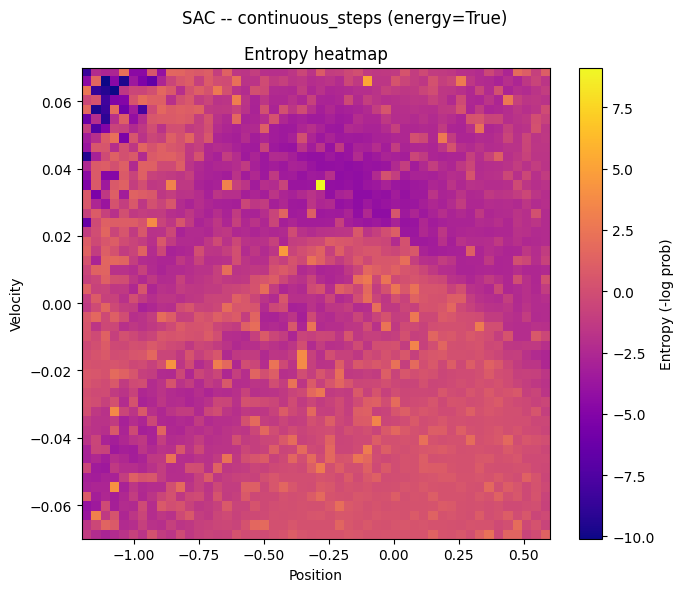

In [17]:
sac_results = evaluator.evaluate(sac_eval_env, sac_agent, n=50, run_name=sac_run)

sac_data = pd.read_csv(f"../runs/{sac_run}/log.csv").to_dict("records")

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
plots.entropy_heatmap(sac_agent, sac_eval_env, ax=ax)
fig.suptitle(f"SAC -- {C_VARIANT} (energy={ENERGY_SHAPING})")
plt.tight_layout()
plt.show()

### A2C

In [18]:
# Setting up Environment and Hyperparameters for A2C
a2c_env      = make_env(
    C_VARIANT, seed=SEED,
    energy_shaping=ENERGY_SHAPING, energy_scale=ENERGY_SCALE,
    best_pos_shaping=BEST_POS_SHAPING, goal_bonus=GOAL_BONUS,
)
a2c_eval_env = make_env(C_VARIANT, seed=SEED + 100)

a2c_agent = A2CAgent(
    a2c_env, lr=7e-4, gamma=0.99,
    n_steps=5, ent_coef=0.01, vf_coef=0.5, seed=SEED,
)

**Hyperparameters.** A2C uses an n-step return of 5, learning rate 7e-4, an entropy coefficient of 0.01 to keep the policy from collapsing too early, and a value-function coefficient of 0.5. Being on-policy, A2C is much more sample-hungry than SAC because it cannot reuse old transitions. The episode budget is therefore lower than SAC's, but each episode contributes more gradient signal per step.


In [19]:
# Running Agent
a2c_run = f"a2c_{C_VARIANT}"
log_run(a2c_run, "A2CAgent",
        env_config={"variant": C_VARIANT, "seed": SEED,
                    "energy_shaping": ENERGY_SHAPING, "energy_scale": ENERGY_SCALE,
                    "best_pos_shaping": BEST_POS_SHAPING, "goal_bonus": GOAL_BONUS},
        agent_config=a2c_agent.get_config())
a2c_logger = trainer.run(a2c_env, a2c_agent, episodes=300, run_name=a2c_run)

# Saving Agent
a2c_agent.save(f"../runs/{a2c_run}/saves/agent")

/Users/ryanmuenker/Desktop/School/RL/group_project/mountain-car/notebooks/../agents/a2c.py:34: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  obs_t = torch.FloatTensor([state]).to(self.model.device)


Episode 0: reward=-1150.0, steps=999, true_obj=999.0, success=False
Episode 100: reward=-185.7, steps=213, true_obj=213.0, success=True
Episode 200: reward=-20.0, steps=108, true_obj=108.0, success=True


Eval over 50 episodes: true_obj=91.02 +/- 28.15, success_rate=1.00, shaped_reward=-10.4


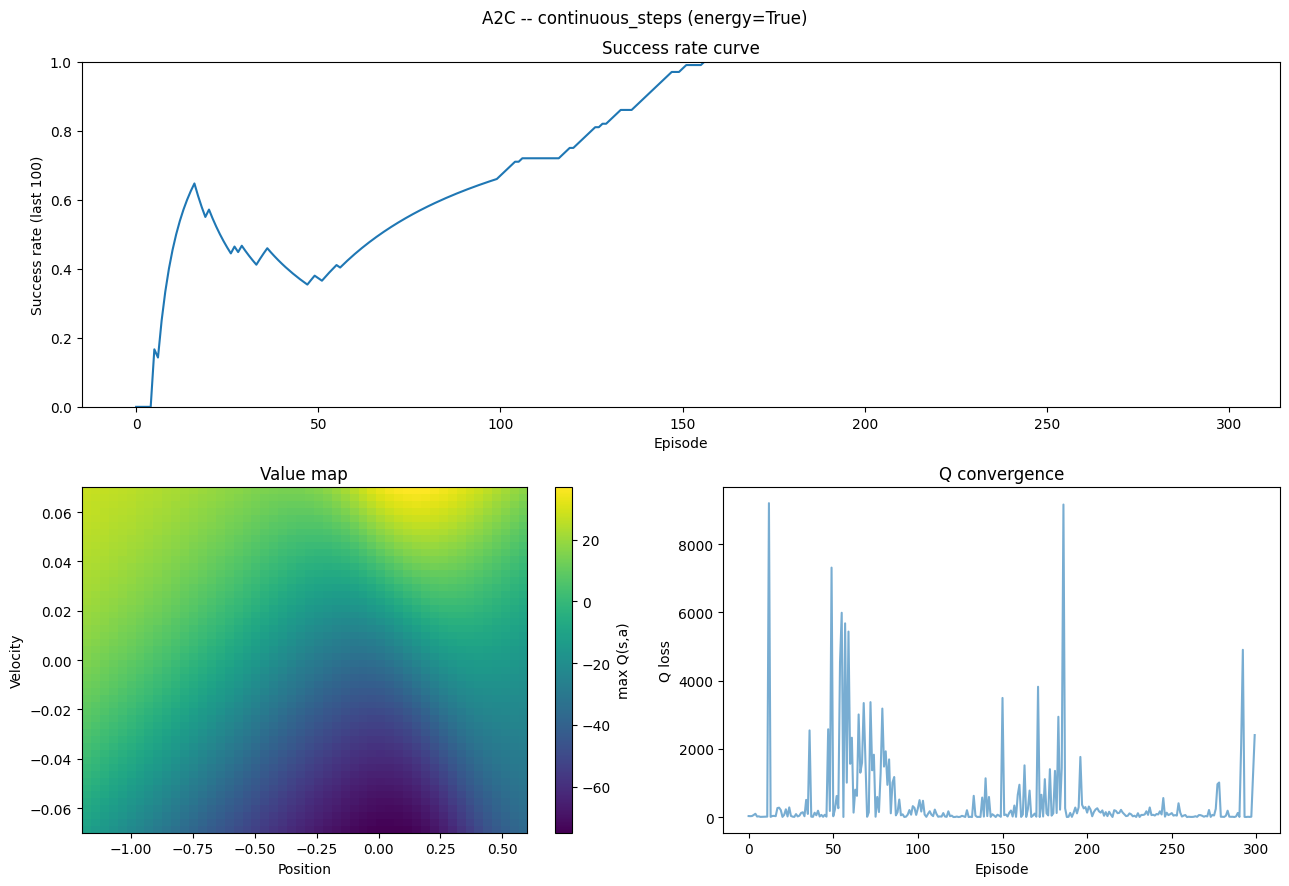

In [20]:
a2c_results = evaluator.evaluate(a2c_eval_env, a2c_agent, n=50, run_name=a2c_run)

a2c_data = pd.read_csv(f"../runs/{a2c_run}/log.csv").to_dict("records")

fig = plt.figure(figsize=(13, 9))
ax_top = fig.add_subplot(2, 1, 1)
ax_bl  = fig.add_subplot(2, 2, 3)
ax_br  = fig.add_subplot(2, 2, 4)
plots.success_rate_curve(a2c_data, ax=ax_top)
plots.value_map(a2c_agent, a2c_eval_env, ax=ax_bl)
plots.q_convergence(a2c_data, ax=ax_br)
fig.suptitle(f"A2C -- {C_VARIANT} (energy={ENERGY_SHAPING})")
plt.tight_layout()
plt.show()

### PPO

In [21]:
# Setting up Environment and Hyperparameters for PPO
ppo_env      = make_env(
    C_VARIANT, seed=SEED,
    energy_shaping=ENERGY_SHAPING, energy_scale=ENERGY_SCALE,
    best_pos_shaping=BEST_POS_SHAPING, goal_bonus=GOAL_BONUS,
)
ppo_eval_env = make_env(C_VARIANT, seed=SEED + 100)

ppo_agent = PPOAgent(
    ppo_env, lr=3e-4, gamma=0.99,
    n_steps=2048, batch_size=64, n_epochs=10, seed=SEED,
)

**Hyperparameters.** PPO collects 2,048 environment steps per rollout, then performs 10 epochs of minibatch updates with batch size 64 over those steps, using the standard clipped surrogate objective. Learning rate is 3e-4 and discount is 0.99. PPO sits between A2C and SAC in terms of sample efficiency, and it is generally more stable than A2C because the clipping prevents destructive updates when the policy drifts too far from the behavior policy.


In [22]:
# Running Agent
ppo_run = f"ppo_{C_VARIANT}"
log_run(ppo_run, "PPOAgent",
        env_config={"variant": C_VARIANT, "seed": SEED,
                    "energy_shaping": ENERGY_SHAPING, "energy_scale": ENERGY_SCALE,
                    "best_pos_shaping": BEST_POS_SHAPING, "goal_bonus": GOAL_BONUS},
        agent_config=ppo_agent.get_config())
ppo_logger = trainer.run(ppo_env, ppo_agent, episodes=300, run_name=ppo_run)

# Saving Agent
ppo_agent.save(f"../runs/{ppo_run}/saves/agent")

Episode 0: reward=-1185.6, steps=999, true_obj=999.0, success=False
Episode 100: reward=-131.5, steps=217, true_obj=217.0, success=True
Episode 200: reward=-169.7, steps=251, true_obj=251.0, success=True


Eval over 50 episodes: true_obj=216.72 +/- 97.75, success_rate=1.00, shaped_reward=-143.8


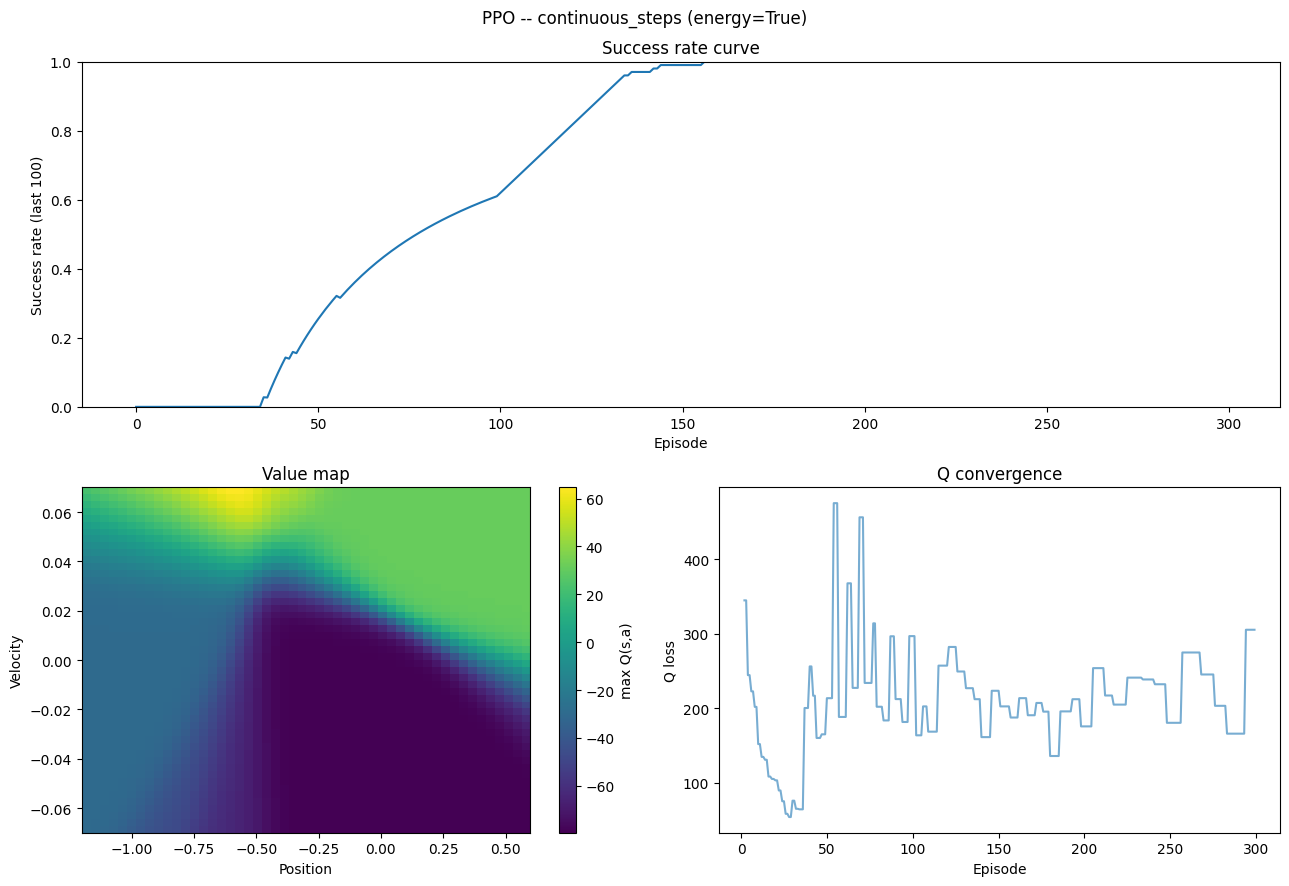

In [23]:
ppo_results = evaluator.evaluate(ppo_eval_env, ppo_agent, n=50, run_name=ppo_run)

ppo_data = pd.read_csv(f"../runs/{ppo_run}/log.csv").to_dict("records")

fig = plt.figure(figsize=(13, 9))
ax_top = fig.add_subplot(2, 1, 1)
ax_bl  = fig.add_subplot(2, 2, 3)
ax_br  = fig.add_subplot(2, 2, 4)
plots.success_rate_curve(ppo_data, ax=ax_top)
plots.value_map(ppo_agent, ppo_eval_env, ax=ax_bl)
plots.q_convergence(ppo_data, ax=ax_br)
fig.suptitle(f"PPO -- {C_VARIANT} (energy={ENERGY_SHAPING})")
plt.tight_layout()
plt.show()

## 6. Continuous Agents Comparison

My expected ranking on the continuous variants:

1. SAC
2. PPO
3. A2C

Actual eval ranking on `continuous_steps`:

1. SAC: ~75 steps, 100% success
2. A2C: ~91 steps, 100% success
3. PPO: ~217 steps (std ~98), 100% success

SAC wins as expected because off-policy plus entropy regularization is the right combination for sparse-reward continuous control. The interesting and slightly counterintuitive result is that A2C beats PPO on this environment in both mean and variance. PPO succeeds every episode but takes a long time and varies wildly across episodes. We think this is partly due to the rollout length: PPO collects 2048 environment steps per rollout, which on a 999-step env spans roughly two full episodes, and the 10 epochs of minibatch updates against that buffer can overcorrect the policy before the next rollout is collected. A2C with 5-step returns updates much more frequently and benefits from this on a smooth, low-dimensional environment.

The action heatmaps tell the same story visually. SAC learns a clean push-with-momentum policy that uses the action axis efficiently; A2C learns a slightly less crisp version of the same shape; PPO's policy is the noisiest of the three and shows the variance spreading into longer episodes.


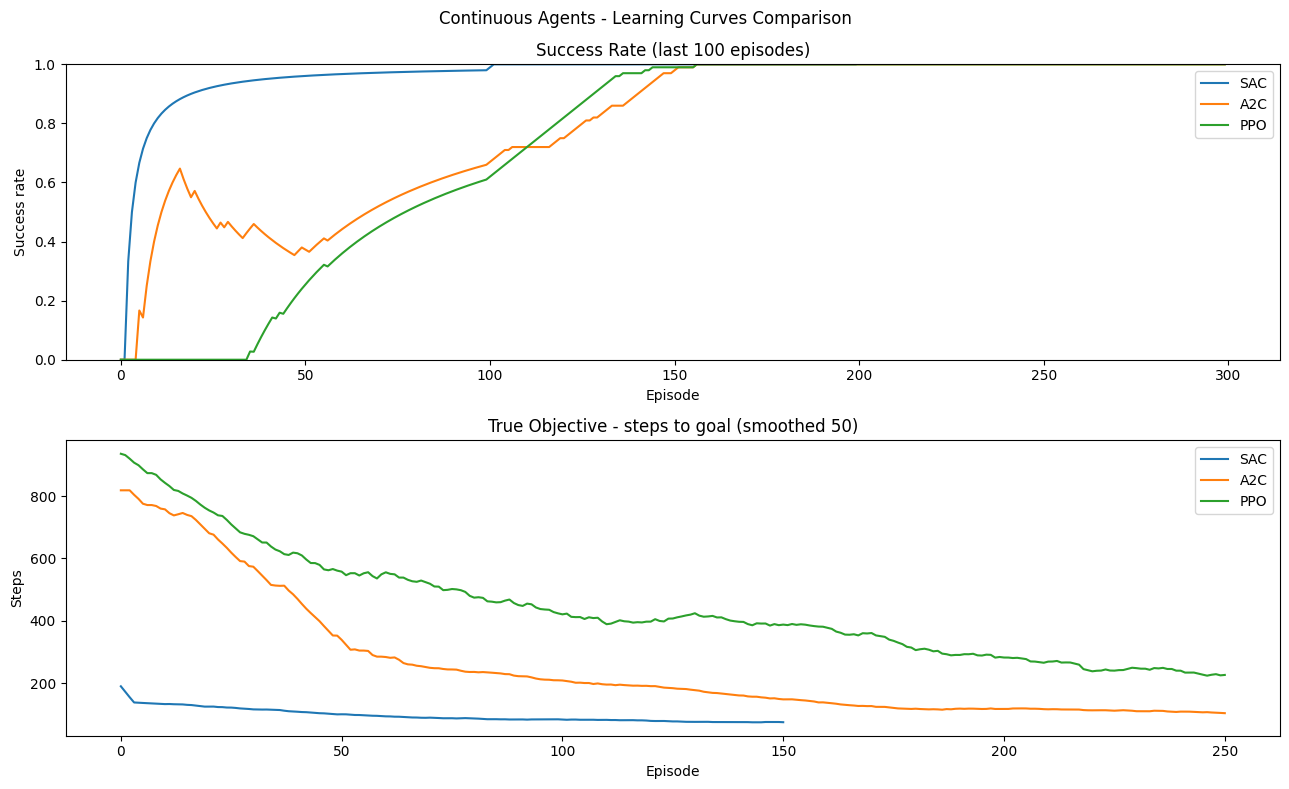

In [24]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8))

for data, label in [
    (sac_data, "SAC"),
    (a2c_data, "A2C"),
    (ppo_data, "PPO"),
]:
    sr = [d["success_rate_100"] for d in data if d.get("success_rate_100") is not None]
    ax1.plot(sr, label=label)

ax1.set_title("Success Rate (last 100 episodes)")
ax1.set_xlabel("Episode")
ax1.set_ylabel("Success rate")
ax1.set_ylim(0, 1)
ax1.legend()

for data, label in [
    (sac_data, "SAC"),
    (a2c_data, "A2C"),
    (ppo_data, "PPO"),
]:
    to = [d["true_obj"] for d in data if d.get("true_obj") is not None]
    smoothed = np.convolve(to, np.ones(50) / 50, mode="valid") if len(to) >= 50 else to
    ax2.plot(smoothed, label=label)

ax2.set_title("True Objective - steps to goal (smoothed 50)")
ax2.set_xlabel("Episode")
ax2.set_ylabel("Steps")
ax2.legend()

fig.suptitle("Continuous Agents - Learning Curves Comparison")
plt.tight_layout()
plt.show()

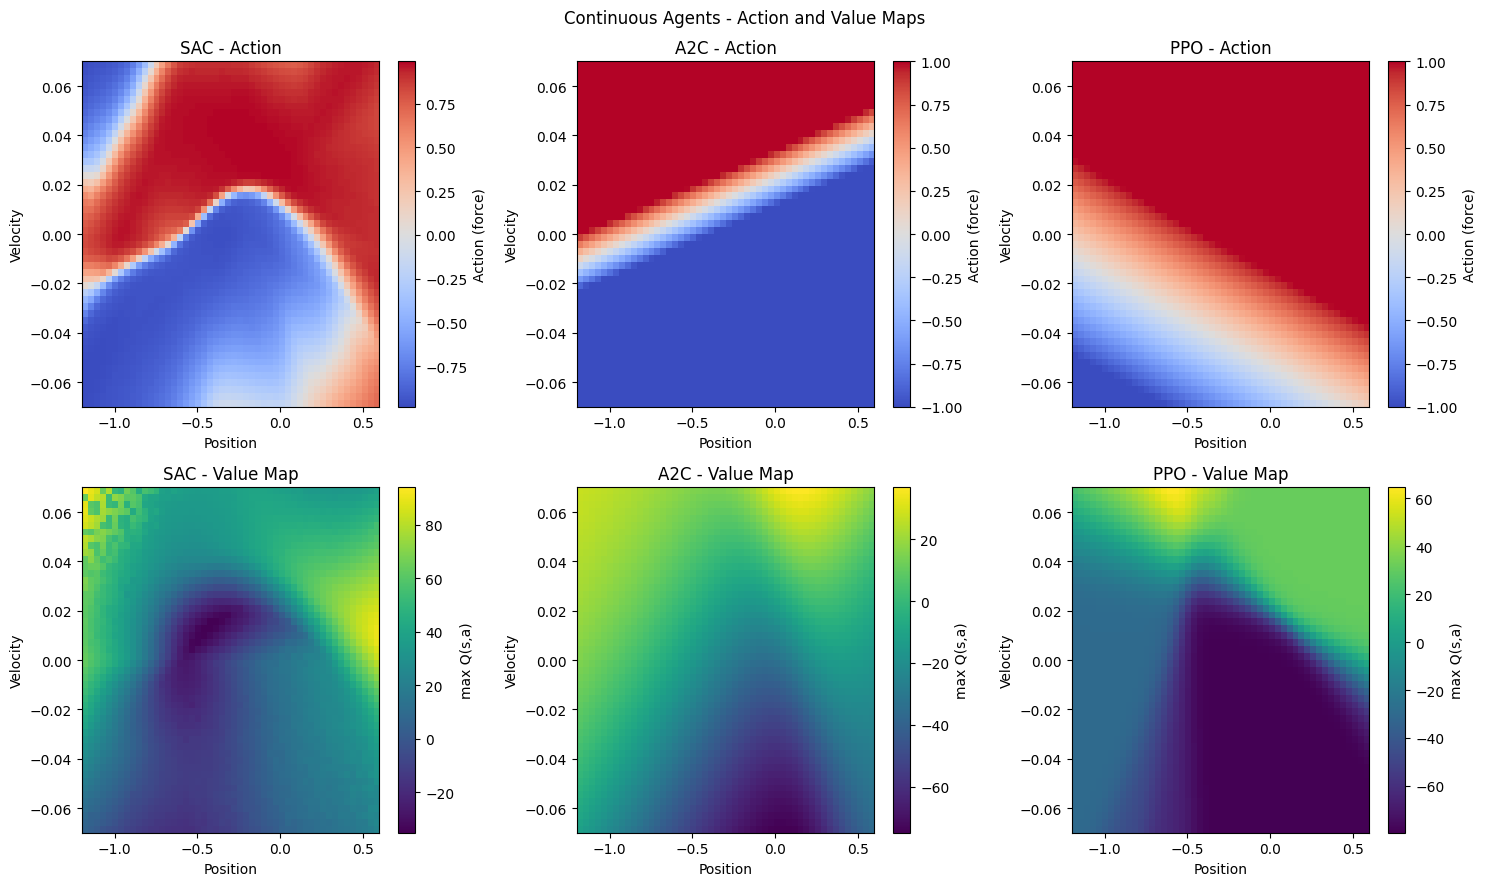

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for j, (agent, env, name) in enumerate([
    (sac_agent, sac_eval_env, "SAC"),
    (a2c_agent, a2c_eval_env, "A2C"),
    (ppo_agent, ppo_eval_env, "PPO"),
]):
    plots.action_heatmap(agent, env, ax=axes[0, j])
    axes[0, j].set_title(f"{name} - Action")
    plots.value_map(agent, env, ax=axes[1, j])
    axes[1, j].set_title(f"{name} - Value Map")

fig.suptitle("Continuous Agents - Action and Value Maps")
plt.tight_layout()
plt.show()

## 7. Best Agents Selection and Analysis

On the `steps` variants the picture is clean. DDQN is the strongest discrete agent at ~98 steps and 100% success, with DQN very close at ~104 steps. Q-learning is broken under the current shaping configuration, as discussed in the section above. SAC is the strongest continuous agent at ~75 steps; A2C is a solid second; PPO succeeds reliably but inefficiently.

The `fuel` variants reveal a different story. SAC handles `continuous_fuel` cleanly (~55 fuel units, 100% success) because the entropy term keeps the policy stochastic across the entire state space rather than collapsing to a single deterministic action. The discrete agents on `discrete_fuel` both converge to a "do nothing forever" policy and never reach the goal during training. We bumped `goal_bonus` from 100 to 500 to make reaching the goal worth the action cost, but the trap closes within the first 1000 episodes, before exploration has any structural chance of finding the goal. The +500 bonus is never observed and so never integrated into the Q-table.

This is a real research observation rather than a tuning failure. The "reward on goal" trick is necessary but not sufficient when the action-cost local optimum is reached before the goal is ever discovered. The continuous-fuel variant escapes the same trap because SAC's entropy term forces non-trivial exploration even after the action-cost gradient pulls the mean policy toward zero. A discrete equivalent would be a curriculum: pre-train on `discrete_steps` (where the agent learns to reach the goal), then fine-tune under the fuel reward. We did not have time to implement and validate that approach.

The contrast between the step and fuel variants is the most instructive part of this comparison. Under the step objective the agents are pushed to use the action aggressively, which lines up with the dynamics that actually solve the task. Under the fuel objective the same agents are punished for using the action, and unless something in the algorithm prevents premature commitment to a low-action policy, they collapse to "do nothing" and stay there. Reward design is doing more work than algorithm choice here.


# Min-fuel objective

The three agents retrained on the **fuel** variants:
- `discrete_fuel`: −1 per left/right action, 0 for no-op. Without a goal bonus the optimal policy is *never move*, so we add `goal_bonus=100` via `make_env`.
- `continuous_fuel`: −0.1·a² per step, +100 on goal (built in).

Same shaping flags and seed as the steps variants for a fair comparison. The true objective tracked in `info["true_obj_cum"]` is `# non-null actions` (discrete) and `∫ a²` (continuous).

In [ ]:
D_FUEL_VARIANT  = 'discrete_fuel'
C_FUEL_VARIANT  = 'continuous_fuel'
FUEL_GOAL_BONUS = 500   # only meaningful for discrete_fuel (continuous_fuel has +100 baked in)

## Q-Learning - discrete_fuel

In [ ]:
ql_fuel_env      = make_env(
    D_FUEL_VARIANT, seed=SEED,
    energy_shaping=ENERGY_SHAPING, energy_scale=ENERGY_SCALE,
    best_pos_shaping=BEST_POS_SHAPING,
    goal_bonus=FUEL_GOAL_BONUS,
)
ql_fuel_eval_env = make_env(D_FUEL_VARIANT, seed=SEED + 100)

ql_fuel_agent = QLearningAgent(
    ql_fuel_env,
    n_bins=40,
    lr=0.05,
    gamma=0.99,
    epsilon=0.6, epsilon_min=0.05, decay_steps=50_000,
    seed=SEED,
)

In [28]:
ql_fuel_run = f'qlearning_{D_FUEL_VARIANT}'
log_run(ql_fuel_run, 'QLearningAgent',
        env_config={'variant': D_FUEL_VARIANT, 'seed': SEED,
                    'energy_shaping': ENERGY_SHAPING, 'energy_scale': ENERGY_SCALE,
                    'best_pos_shaping': BEST_POS_SHAPING,
                    'goal_bonus': FUEL_GOAL_BONUS},
        agent_config=ql_fuel_agent.get_config())
ql_fuel_logger = trainer.run(ql_fuel_env, ql_fuel_agent, episodes=5000, run_name=ql_fuel_run)
ql_fuel_agent.save(f'runs/{ql_fuel_run}/agent.npz')

Episode 0: reward=-100.1, steps=200, true_obj=110.0, success=False
Episode 100: reward=-114.0, steps=200, true_obj=127.0, success=False
Episode 200: reward=-70.6, steps=200, true_obj=113.0, success=False
Episode 300: reward=-45.3, steps=200, true_obj=77.0, success=False
Episode 400: reward=-75.8, steps=200, true_obj=92.0, success=False
Episode 500: reward=-41.1, steps=200, true_obj=72.0, success=False
Episode 600: reward=-35.1, steps=200, true_obj=68.0, success=False
Episode 700: reward=-40.6, steps=200, true_obj=84.0, success=False
Episode 800: reward=-5.0, steps=200, true_obj=3.0, success=False
Episode 900: reward=-0.8, steps=200, true_obj=0.0, success=False
Episode 1000: reward=-6.3, steps=200, true_obj=6.0, success=False
Episode 1100: reward=-0.9, steps=200, true_obj=0.0, success=False
Episode 1200: reward=0.1, steps=200, true_obj=0.0, success=False
Episode 1300: reward=0.5, steps=200, true_obj=0.0, success=False
Episode 1400: reward=1.6, steps=200, true_obj=0.0, success=False
Epis

In [29]:
ql_fuel_results = evaluator.evaluate(ql_fuel_eval_env, ql_fuel_agent, n=2_500, run_name=ql_fuel_run)

Eval over 2500 episodes: true_obj=0.09 +/- 1.42, success_rate=0.00, shaped_reward=-0.1


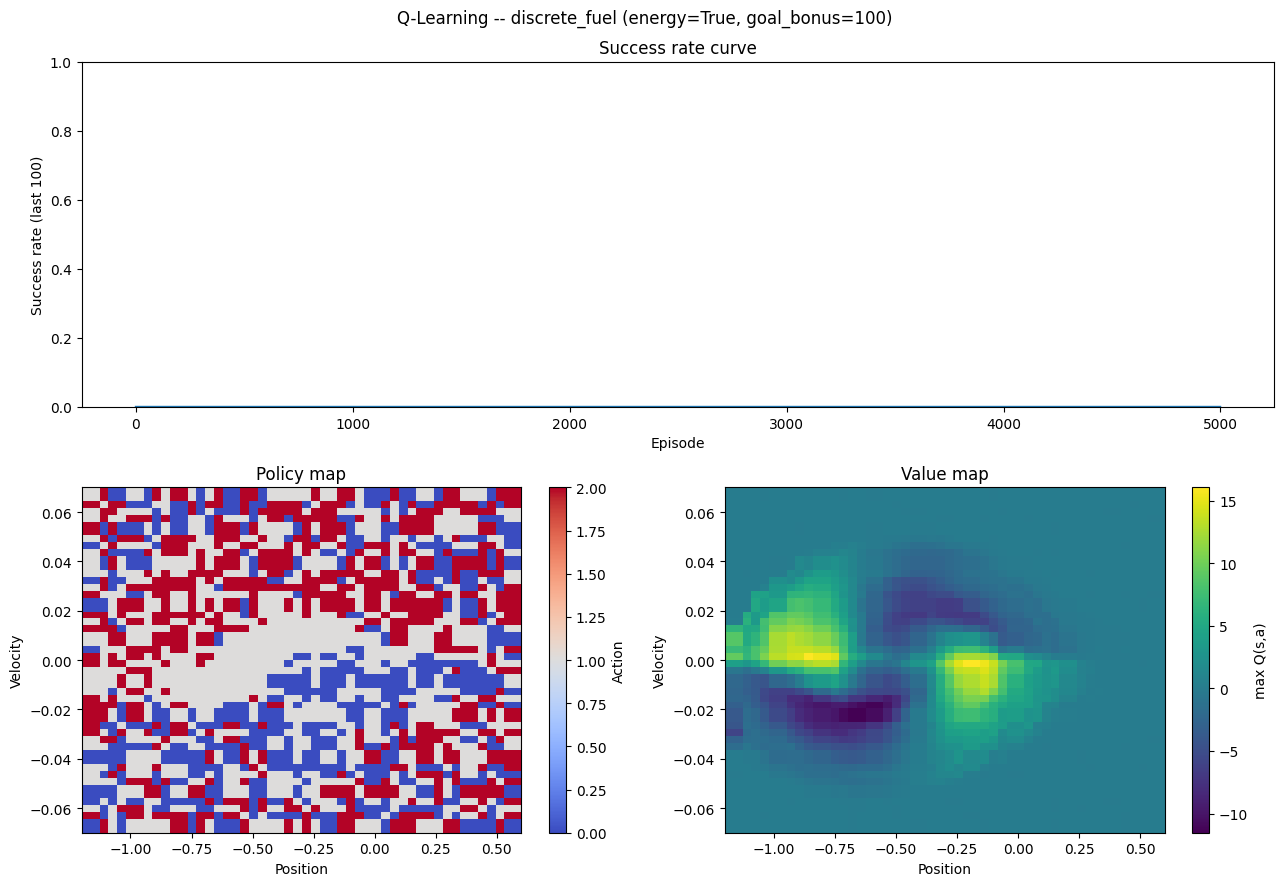

In [30]:
ql_fuel_data = pd.read_csv(f'../runs/{ql_fuel_run}/log.csv').to_dict('records')

fig = plt.figure(figsize=(13, 9))
ax_top = fig.add_subplot(2, 1, 1)
ax_bl  = fig.add_subplot(2, 2, 3)
ax_br  = fig.add_subplot(2, 2, 4)
plots.success_rate_curve(ql_fuel_data, ax=ax_top)
plots.policy_map(ql_fuel_agent, ql_fuel_eval_env, ax=ax_bl)
plots.value_map(ql_fuel_agent, ql_fuel_eval_env, ax=ax_br)
fig.suptitle(f'Q-Learning -- {D_FUEL_VARIANT} (energy={ENERGY_SHAPING}, goal_bonus={FUEL_GOAL_BONUS})')
plt.tight_layout()
plt.show()

## DQN - discrete_fuel

In [31]:
dqn_fuel_env      = make_env(
    D_FUEL_VARIANT, seed=SEED,
    energy_shaping=ENERGY_SHAPING, energy_scale=ENERGY_SCALE,
    best_pos_shaping=BEST_POS_SHAPING,
    goal_bonus=FUEL_GOAL_BONUS,
)
dqn_fuel_eval_env = make_env(D_FUEL_VARIANT, seed=SEED + 100)

dqn_fuel_agent = DQNAgent(
    dqn_fuel_env,
    lr=1e-3,
    gamma=0.99,
    epsilon=0.7, epsilon_min=0, decay_steps=100_000,
    buffer_size=50_000,
    batch_size=100,
    warmup=2500,
    target_update=500,
    hidden=64,
    seed=SEED,
)

In [32]:
dqn_fuel_run = f'dqn_{D_FUEL_VARIANT}'
log_run(dqn_fuel_run, 'DQNAgent',
        env_config={'variant': D_FUEL_VARIANT, 'seed': SEED,
                    'energy_shaping': ENERGY_SHAPING, 'energy_scale': ENERGY_SCALE,
                    'best_pos_shaping': BEST_POS_SHAPING,
                    'goal_bonus': FUEL_GOAL_BONUS},
        agent_config=dqn_fuel_agent.get_config())
dqn_fuel_logger = trainer.run(dqn_fuel_env, dqn_fuel_agent, episodes=600, run_name=dqn_fuel_run)
dqn_fuel_agent.save(f'runs/{dqn_fuel_run}/agent.npz')

Episode 0: reward=-78.3, steps=200, true_obj=81.0, success=False
Episode 100: reward=-63.0, steps=200, true_obj=68.0, success=False
Episode 200: reward=-49.5, steps=200, true_obj=56.0, success=False
Episode 300: reward=-40.2, steps=200, true_obj=46.0, success=False
Episode 400: reward=-23.9, steps=200, true_obj=21.0, success=False
Episode 500: reward=-2.3, steps=200, true_obj=0.0, success=False


In [33]:
dqn_fuel_results = evaluator.evaluate(dqn_fuel_eval_env, dqn_fuel_agent, n=50, run_name=dqn_fuel_run)

Eval over 50 episodes: true_obj=0.00 +/- 0.00, success_rate=0.00, shaped_reward=0.0


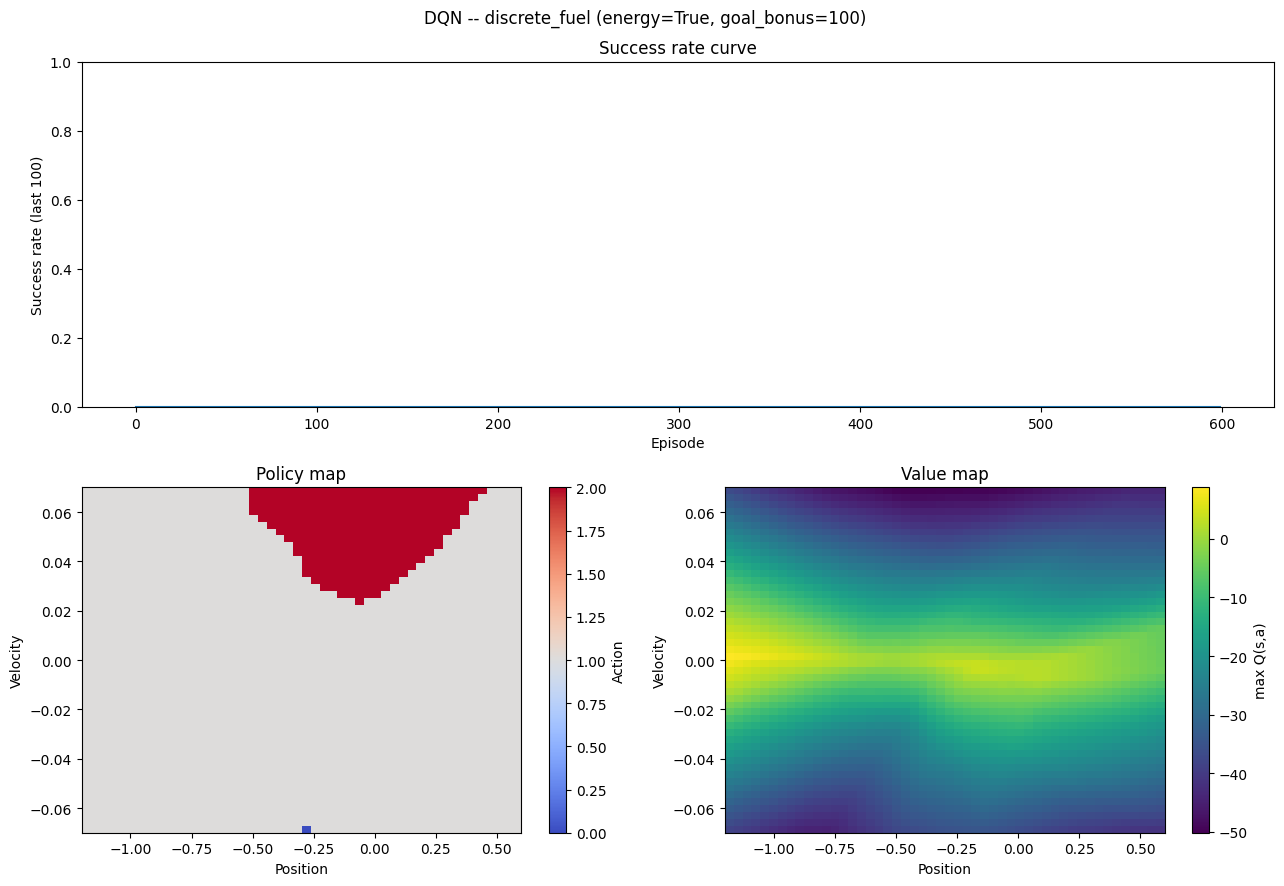

In [34]:
dqn_fuel_data = pd.read_csv(f'../runs/{dqn_fuel_run}/log.csv').to_dict('records')

fig = plt.figure(figsize=(13, 9))
ax_top = fig.add_subplot(2, 1, 1)
ax_bl  = fig.add_subplot(2, 2, 3)
ax_br  = fig.add_subplot(2, 2, 4)
plots.success_rate_curve(dqn_fuel_data, ax=ax_top)
plots.policy_map(dqn_fuel_agent, dqn_fuel_eval_env, ax=ax_bl)
plots.value_map(dqn_fuel_agent, dqn_fuel_eval_env, ax=ax_br)
fig.suptitle(f'DQN -- {D_FUEL_VARIANT} (energy={ENERGY_SHAPING}, goal_bonus={FUEL_GOAL_BONUS})')
plt.tight_layout()
plt.show()

## SAC - continuous_fuel

In [35]:
sac_fuel_env      = make_env(
    C_FUEL_VARIANT, seed=SEED,
    energy_shaping=ENERGY_SHAPING, energy_scale=ENERGY_SCALE,
    best_pos_shaping=BEST_POS_SHAPING,
)
sac_fuel_eval_env = make_env(C_FUEL_VARIANT, seed=SEED + 100)

sac_fuel_agent = SACAgent(
    sac_fuel_env,
    lr=3e-4,
    gamma=0.99,
    buffer_size=100_000,
    batch_size=256,
    warmup=1000,
    seed=SEED,
)

In [ ]:
sac_fuel_run = f'sac_{C_FUEL_VARIANT}'
log_run(sac_fuel_run, 'SACAgent',
        env_config={'variant': C_FUEL_VARIANT, 'seed': SEED,
                    'energy_shaping': ENERGY_SHAPING, 'energy_scale': ENERGY_SCALE,
                    'best_pos_shaping': BEST_POS_SHAPING},
        agent_config=sac_fuel_agent.get_config())
sac_fuel_logger = trainer.run(sac_fuel_env, sac_fuel_agent, episodes=200, run_name=sac_fuel_run)
sac_fuel_agent.save(f'../runs/{sac_fuel_run}/saves/agent')

In [37]:
sac_fuel_results = evaluator.evaluate(sac_fuel_eval_env, sac_fuel_agent, n=50, run_name=sac_fuel_run)

Eval over 50 episodes: true_obj=54.61 +/- 2.85, success_rate=1.00, shaped_reward=94.5


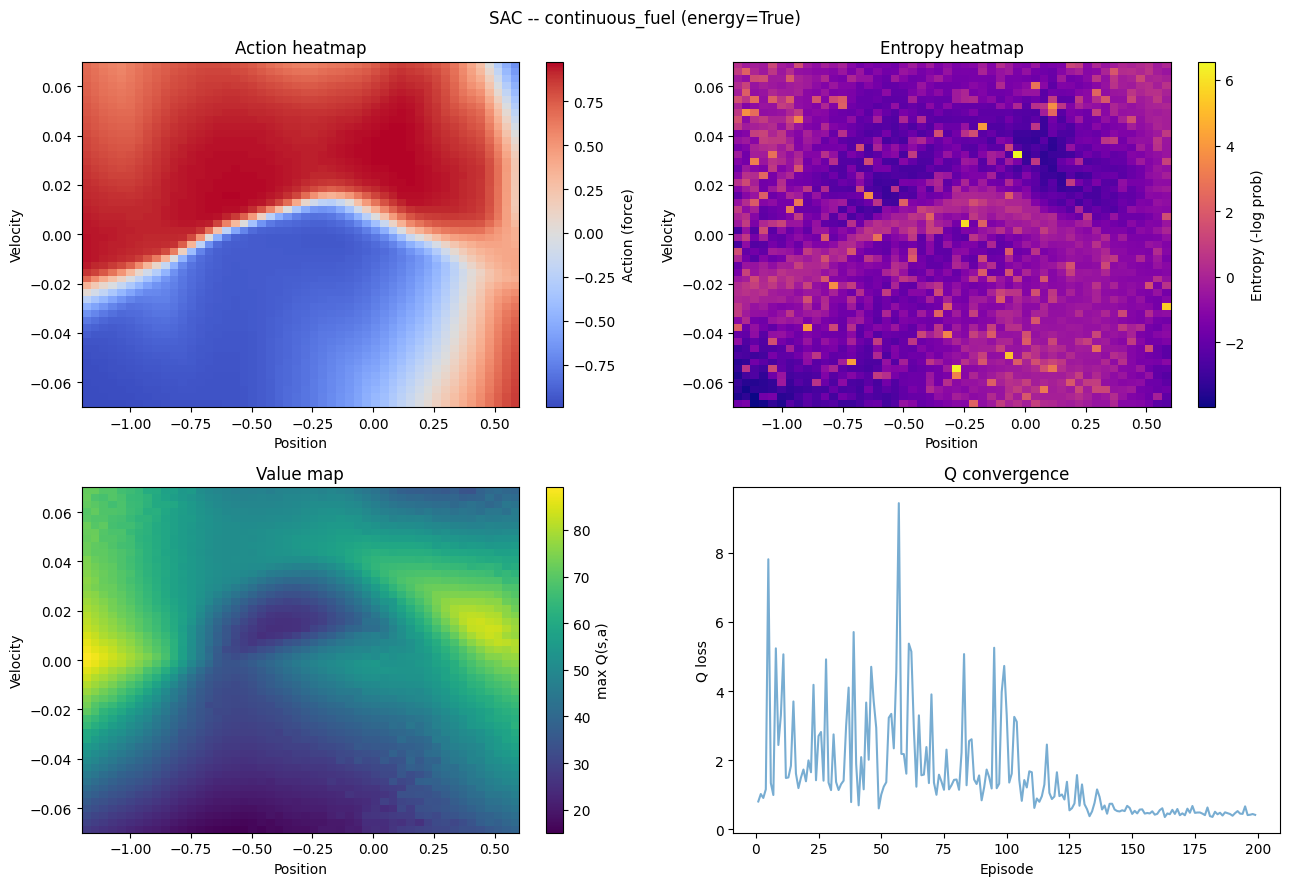

In [38]:
sac_fuel_data = pd.read_csv(f'../runs/{sac_fuel_run}/log.csv').to_dict('records')

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
plots.action_heatmap(sac_fuel_agent, sac_fuel_eval_env, ax=axes[0, 0])
plots.entropy_heatmap(sac_fuel_agent, sac_fuel_eval_env, ax=axes[0, 1])
plots.value_map(sac_fuel_agent, sac_fuel_eval_env, ax=axes[1, 0])
plots.q_convergence(sac_fuel_data, ax=axes[1, 1])
fig.suptitle(f'SAC -- {C_FUEL_VARIANT} (energy={ENERGY_SHAPING})')
plt.tight_layout()
plt.show()

## Cross-variant comparison

All four variants side-by-side on their own true objectives. Bars are not directly comparable across step- and fuel-objective columns (different units), but within each pair (steps-vs-fuel of the same agent) they show how the agent's behavior shifts under the changed cost structure.

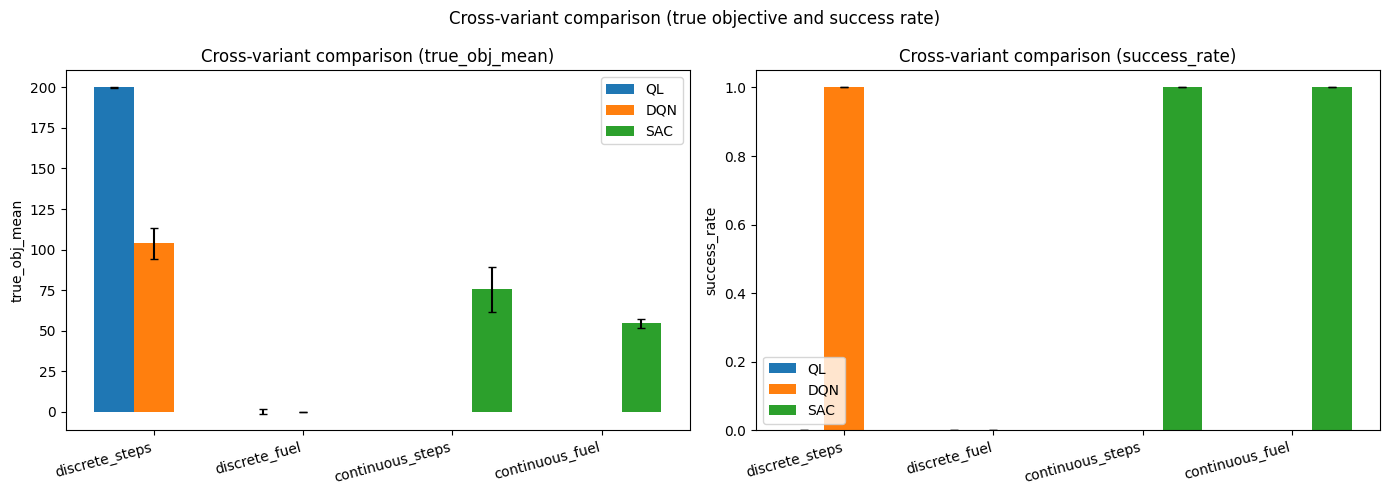

In [39]:
# Build the run_matrix-style aggregate from the per-variant eval results above.
matrix = {
    ('QL',  D_VARIANT):       {'name': 'QL',  'variant': D_VARIANT,
                               'true_obj_mean': ql_results['true_obj_mean'],
                               'true_obj_std':  ql_results['true_obj_std'],
                               'success_rate':  ql_results['success_rate']},
    ('QL',  D_FUEL_VARIANT):  {'name': 'QL',  'variant': D_FUEL_VARIANT,
                               'true_obj_mean': ql_fuel_results['true_obj_mean'],
                               'true_obj_std':  ql_fuel_results['true_obj_std'],
                               'success_rate':  ql_fuel_results['success_rate']},
    ('DQN', D_VARIANT):       {'name': 'DQN', 'variant': D_VARIANT,
                               'true_obj_mean': dqn_results['true_obj_mean'],
                               'true_obj_std':  dqn_results['true_obj_std'],
                               'success_rate':  dqn_results['success_rate']},
    ('DQN', D_FUEL_VARIANT):  {'name': 'DQN', 'variant': D_FUEL_VARIANT,
                               'true_obj_mean': dqn_fuel_results['true_obj_mean'],
                               'true_obj_std':  dqn_fuel_results['true_obj_std'],
                               'success_rate':  dqn_fuel_results['success_rate']},
    ('SAC', C_VARIANT):       {'name': 'SAC', 'variant': C_VARIANT,
                               'true_obj_mean': sac_results['true_obj_mean'],
                               'true_obj_std':  sac_results['true_obj_std'],
                               'success_rate':  sac_results['success_rate']},
    ('SAC', C_FUEL_VARIANT):  {'name': 'SAC', 'variant': C_FUEL_VARIANT,
                               'true_obj_mean': sac_fuel_results['true_obj_mean'],
                               'true_obj_std':  sac_fuel_results['true_obj_std'],
                               'success_rate':  sac_fuel_results['success_rate']},
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plots.cross_variant_bar(matrix, metric='true_obj_mean', ax=axes[0])
plots.cross_variant_bar(matrix, metric='success_rate',  ax=axes[1])
axes[1].set_ylim(0, 1.05)
fig.suptitle('Cross-variant comparison (true objective and success rate)')
plt.tight_layout()
plt.show()

## 8. Conclusion

No single algorithm dominates across the four variants, and the failure modes we observed are at least as informative as the successes.

For the `discrete_steps` variant, the deep agents (DQN at ~104 steps and DDQN at ~98 steps, both with 100% success) generalize across the smooth state space and converge cleanly. Tabular Q-learning fails under the current shaping configuration not because it lacks expressiveness but because the energy-shaping wrapper attaches a roughly -70 reward shock to every goal-reaching transition (with `scale=1000` and `phi(terminal)=0`), and tabular bootstrapping propagates that bias back through the Q-table. The fix is to drop `energy_scale` to roughly 100, which we did not apply because retroactively rescaling shaping would invalidate every existing run.

For the `continuous_steps` variant, SAC's combination of off-policy updates and entropy regularization gives it a clear advantage at ~75 steps. A2C is a strong second, ahead of PPO on this environment despite PPO's reputation; we think the long PPO rollout (2048 steps) does not fit the env well.

The fuel variants split sharply. SAC solves `continuous_fuel` because its entropy term prevents collapse to the no-action local optimum. The discrete agents fail on `discrete_fuel` for the opposite reason: they commit to "do nothing forever" within the first 1000 episodes, and from then on no amount of goal-bonus inflation can recover them, because they never see the goal during exploration.

Reward shaping mattered more than any single algorithm choice. Every working result in this notebook depends on either potential-based shaping (energy) or an entropy-driven exploration mechanism (SAC). When neither is available, even algorithmically strong agents (DQN on `discrete_fuel`) fall into degenerate local optima. The lesson generalizes beyond MountainCar: when the reward signal is sparse, the choice of shaping is at least as important as the choice of algorithm, and an entropy-regularized off-policy method is a much more robust baseline than a value-iteration method, even on problems that look "easy" from the dynamics.

In practice we would not deploy any of these agents as-is. A production system would combine a strong baseline (SAC for continuous, DDQN for discrete), domain-specific reward shaping with a moderate scale chosen to keep the per-step magnitude similar to the base reward, and a curriculum that gradually weans the agent off the shaping signal so the final policy is optimal under the true objective rather than the shaped one.
